# Boston Housing Price Prediction using Deep Neural Network

## Step 1: Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


## Step 2: Load Dataset

In [2]:

# Load Dataset
df = pd.read_csv("HousingData.csv")
# Display first 5 rows
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Step 3: Prepare Input and Output Data

In [3]:

# Input Features
X = df.drop('MEDV', axis=1)

# Target Variable
y = df['MEDV']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (506, 13)
Target Shape: (506,)


## Step 4: Split Dataset

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


## Step 5: Feature Scaling

In [5]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Scaling Completed")


Data Scaling Completed


## Step 6: Build Deep Neural Network Model

In [6]:

model = Sequential()

# Hidden Layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

model.summary()


C:\Users\Arclooks\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile Model

In [7]:

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

print("Model Compiled Successfully")


Model Compiled Successfully


## Step 8: Train Model

In [8]:
help(model.fit)

Help on method fit in module keras.src.backend.tensorflow.trainer:

fit(x=None, y=None, batch_size=None, epochs=1, verbose='auto', callbacks=None, validation_split=0.0, validation_data=None, shuffle=True, class_weight=None, sample_weight=None, initial_epoch=0, steps_per_epoch=None, validation_steps=None, validation_batch_size=None, validation_freq=1) method of keras.src.models.sequential.Sequential instance
    Trains the model for a fixed number of epochs (dataset iterations).
    
    Args:
        x: Input data. It can be:
            - A NumPy array (or array-like), or a list of arrays
            (in case the model has multiple inputs).
            - A backend-native tensor, or a list of tensors
            (in case the model has multiple inputs).
            - A dict mapping input names to the corresponding array/tensors,
            if the model has named inputs.
            - A `keras.utils.PyDataset` returning `(inputs, targets)` or
            `(inputs, targets, sample_weight

In [9]:

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 591.6290 - mae: 22.3706 - val_loss: 493.2248 - val_mae: 20.5811
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 492.8400 - mae: 19.9953 - val_loss: 361.4575 - val_mae: 17.0826
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 331.8131 - mae: 15.5330 - val_loss: 198.8854 - val_mae: 11.5985
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 178.2810 - mae: 10.2649 - val_loss: 91.6826 - val_mae: 6.6996
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 101.0569 - mae: 7.1884 - val_loss: 69.6600 - val_mae: 5.9005
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 91.6320 - mae: 7.0922 - val_loss: 71.5091 - val_mae: 6.3085
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 91.2513 - mae: 7.1165 - val_loss: 70.5399 - val_mae: 6.1535
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 91.0895 - mae: 7.0065 - val_loss: 69.9033 - val_mae: 6.0010
Epoch 9/100
21/21 ━━━━━━━━━

Epoch 2/100


 1/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 77.8768 - mae: 6.5046

 9/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 52.0534 - mae: 5.4601  

18/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 43.9282 - mae: 4.9542

...

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.7302 - mae: 1.6880 - val_loss: 8.9329 - val_mae: 2.2436


Epoch 100/100


 1/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 2.4102 - mae: 1.2724

17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2701 - mae: 1.7138 

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.2975 - mae: 1.6926 - val_loss: 10.8500 - val_mae: 2.3487


## Step 9: Evaluate Model

In [10]:

loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Mean Absolute Error:", mae)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 74.6642 - mae: 6.2103

Test Loss: 74.66419219970703
Mean Absolute Error: 6.210294723510742


## Step 10: Predict House Prices

In [11]:

predictions = model.predict(X_test)

print("\nSample Predictions:\n")

for i in range(5):
    print("Actual Price =", y_test.iloc[i],
          " Predicted Price =", predictions[i][0])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Sample Predictions:

Actual Price = 23.6  Predicted Price = 22.641668
Actual Price = 32.4  Predicted Price = 22.641668
Actual Price = 13.6  Predicted Price = 22.641668
Actual Price = 22.8  Predicted Price = 22.641668
Actual Price = 16.1  Predicted Price = 22.641668


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step



Sample Predictions:

Actual Price = 23.6  Predicted Price = 27.60094
Actual Price = 32.4  Predicted Price = 36.47701
Actual Price = 13.6  Predicted Price = 13.61287
Actual Price = 22.8  Predicted Price = 24.85852
Actual Price = 16.1  Predicted Price = 16.51278



## Required Library Installation

Run this command before executing the notebook:

```python
pip install tensorflow pandas numpy scikit-learn
```


## Step 11: Plot Loss Graph

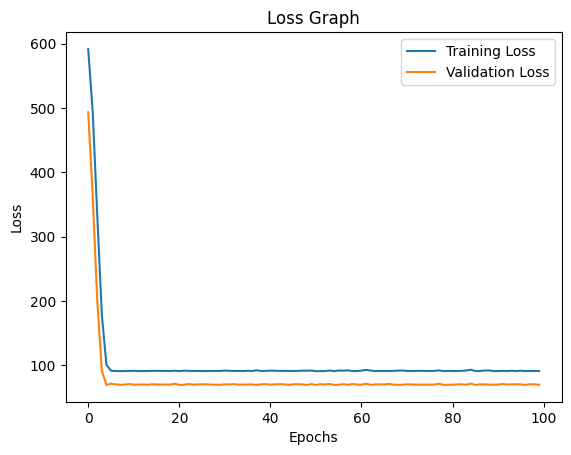

In [12]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()
